# REGIME-SHIFT
### Macro-Aware Tactical Asset Allocation Engine





## 0. Setup

In [1]:
import sys, warnings, logging
sys.path.append("..")  # so `engine` is importable when this notebook lives in a `notebooks/` folder
warnings.filterwarnings("ignore")

# hmmlearn logs a "Model is not converging" line per EM iteration on short
# windows (harmless — walk-forward refits use small samples early on and a
# capped n_iter, so occasional non-convergence is expected). Silenced here
# purely so 150+ refits don't flood the notebook output.
logging.getLogger("hmmlearn").setLevel(logging.ERROR)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from engine import data, regime as regime_mod, optimizer as opt_mod, backtest, metrics

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

REGIME_COLORS = {"Bull": "#2ca02c", "Bear": "#ff7f0e", "Crisis": "#d62728", "Warming up": "#cccccc"}


## 1. Data Ingestion

Universe:
- **Equities** - SPY (S&P 500 ETF)
- **Bonds** - AGG (US Aggregate Bond ETF) - the ballast
- **Gold** - GLD - the crisis hedge
- **VIX** - regime-detection feature (fear gauge)
- **FRED macro** - 10y-2y yield spread & high-yield credit spread (regime-detection features)

`engine/data.py` tries `yfinance` + FRED first; if that fails (no internet in this
execution environment) it transparently falls back to a synthetic regime-switching
dataset for pipeline development. Check the flag below before trusting any numbers
in this notebook.

In [ ]:
START, END = "2010-01-01", "2024-12-31"
df, IS_SYNTHETIC = data.load_dataset(START, END)

print(f"{'⚠️  SYNTHETIC DATA — pipeline demo only, not a real backtest result' if IS_SYNTHETIC else ' LIVE market data from Yahoo Finance / FRED'}")
print(f"Rows: {len(df):,}  |  Range: {df.index.min().date()} → {df.index.max().date()}")
df.drop(columns=[c for c in df.columns if c.startswith('_true_regime')], errors='ignore').tail()


Failed to get ticker 'AGG' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


HTTP Error 403: Host not in allowlist: query1.finance.yahoo.com. Add this host to your network egress settings to allow access.


Failed to get ticker 'GLD' reason: Expecting value: line 1 column 1 (char 0)


HTTP Error 403: Host not in allowlist: query2.finance.yahoo.com. Add this host to your network egress settings to allow access.


...


4 Failed downloads:


['AGG', 'GLD']: JSONDecodeError('Expecting value: line 1 column 1 (char 0)')


['SPY', '^VIX']: possibly delisted; no timezone found


⚠️  SYNTHETIC DATA — pipeline demo only, not a real backtest result
Rows: 3,913  |  Range: 2010-01-01 → 2024-12-31


,equity,bonds,gold,vix,yield_spread,credit_spread
2024-12-25,378.218110,144.218759,197.521447,85.0,1.0,13.764430
2024-12-26,386.327650,143.775075,195.534375,85.0,1.0,10.680487
2024-12-27,386.410830,144.051225,194.802045,85.0,1.0,9.772720
2024-12-30,380.669744,144.424244,194.992428,85.0,1.0,10.746070
2024-12-31,379.021570,143.931927,195.002087,85.0,1.0,14.428560


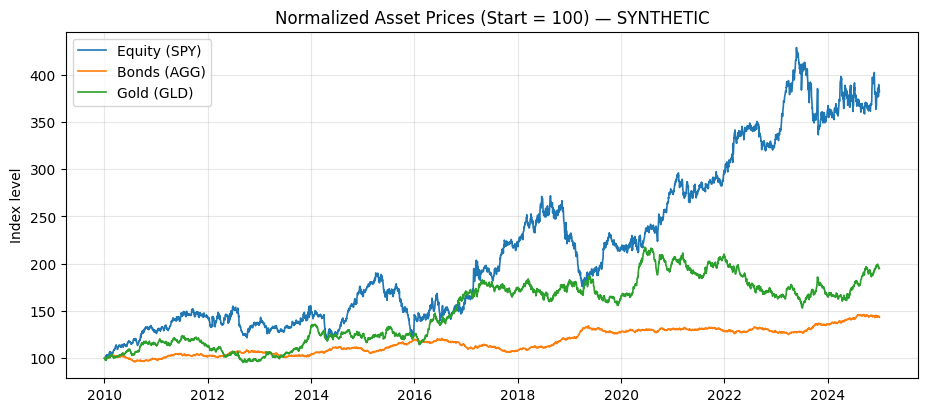

In [3]:
norm = df[["equity", "bonds", "gold"]] / df[["equity", "bonds", "gold"]].iloc[0] * 100
fig, ax = plt.subplots()
for col, label in [("equity", "Equity (SPY)"), ("bonds", "Bonds (AGG)"), ("gold", "Gold (GLD)")]:
    ax.plot(norm.index, norm[col], label=label, linewidth=1.2)
ax.set_title(f"Normalized Asset Prices (Start = 100){' — SYNTHETIC' if IS_SYNTHETIC else ''}")
ax.set_ylabel("Index level")
ax.legend()
plt.show()


## 2. HMM Regime Classifier

Three-state Gaussian HMM trained on a **stationary feature set** (never raw price
levels, which would break the model's stationarity assumption):

1. `ret_21d` - 21-day rolling mean return (trend)
2. `vol_21d` - 21-day realized annualized volatility
3. `vix_z` - VIX level, z-scored against its own trailing year (fear, normalized)

hmmlearn doesn't know which of its 3 states is "Bull" - the state IDs are arbitrary.
`engine/regime.py` resolves this after fitting by ranking each state's fitted mean
on `return - vol - vix_z`: highest → **Bull**, lowest → **Crisis**.

**Important:** the HMM shown in this section is fit ONCE on the *full* history,
purely so we can visualize what the model sees. This is standard exploratory
practice - but it is **not** what the backtest in Section 4 uses to trade, because
fitting on the full history (including the future relative to any historical
rebalance date) would be exactly the look-ahead bias this project is designed to
eliminate. Section 4 refits a brand-new HMM at every rebalance date using only
data up to that point.

In [4]:
features = regime_mod.build_features(df)
full_model, label_map = regime_mod.fit_hmm(features)
regime_labels = regime_mod.classify(full_model, label_map, features)

print("State -> Regime label mapping:", label_map)
print("\nRegime frequency (full-sample, exploratory fit):")
print(regime_labels.value_counts())


State -> Regime label mapping: {2: 'Bull', 1: 'Bear', 0: 'Crisis'}

Regime frequency (full-sample, exploratory fit):
regime
Bull      2047
Crisis    1432
Bear       393
Name: count, dtype: int64


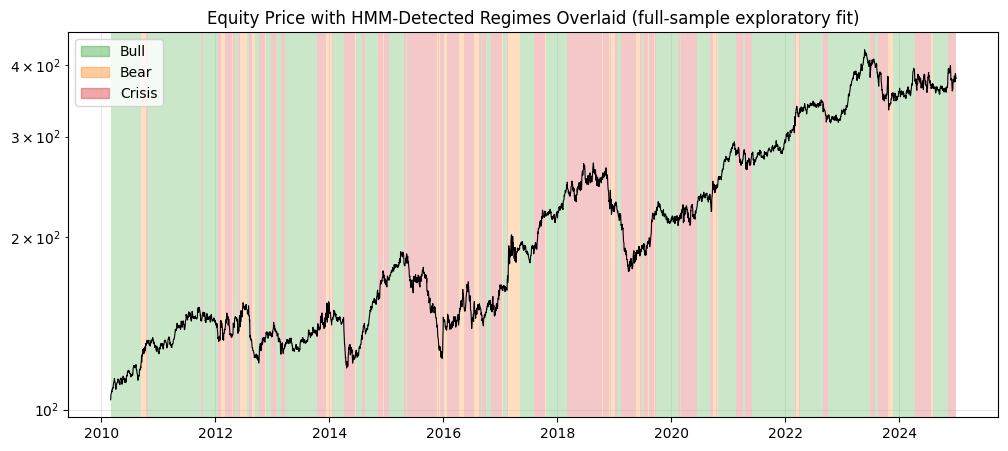

In [5]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(df.loc[features.index, "equity"], color="black", linewidth=0.8, zorder=3)
ax.set_yscale("log")
ax.set_title("Equity Price with HMM-Detected Regimes Overlaid (full-sample exploratory fit)")

prev_date = regime_labels.index[0]
prev_regime = regime_labels.iloc[0]
for dt, reg in regime_labels.items():
    if reg != prev_regime:
        ax.axvspan(prev_date, dt, color=REGIME_COLORS[prev_regime], alpha=0.25, lw=0)
        prev_date, prev_regime = dt, reg
ax.axvspan(prev_date, regime_labels.index[-1], color=REGIME_COLORS[prev_regime], alpha=0.25, lw=0)

handles = [plt.Rectangle((0,0),1,1, color=REGIME_COLORS[r], alpha=0.4) for r in ["Bull","Bear","Crisis"]]
ax.legend(handles, ["Bull","Bear","Crisis"], loc="upper left")
plt.show()


**Transition probability matrix** (row = current regime, column = next-period regime, exploratory full-sample fit):

In [6]:
inv_map = {v: k for k, v in label_map.items()}
order = ["Bull", "Bear", "Crisis"]
P = full_model.transmat_[[inv_map[r] for r in order]][:, [inv_map[r] for r in order]]
trans_df = pd.DataFrame(P, index=order, columns=order).round(3)
trans_df


,Bull,Bear,Crisis
Bull,0.983,0.000,0.017
Bear,0.025,0.916,0.059
Crisis,0.017,0.023,0.960


## 3. Dynamic Constraint Mapping

Each regime maps to a different convex optimization problem, solved with **CVXPY**:

| Regime | Objective | Rationale |
|---|---|---|
| **Bull** | Maximize Sharpe Ratio | Growth-seeking; long-only Sharpe-max via the Cornuejols–Tütüncü convex reformulation (see `engine/optimizer.py` docstring for the derivation) |
| **Bear** | Minimize Variance | De-risk, no explicit return target |
| **Crisis** | Minimize Variance **+ ≥30% floor on Gold** | Explicit flight-to-safety - pure min-vol can still end up bond-heavy if bond vol is briefly low, so the crisis-hedge floor is enforced directly as a constraint |

All portfolios are **long-only** (`w ≥ 0`) and **fully invested** (`sum(w) = 1`) -
no leverage, no shorting.

A quick illustration using the most recent 6-month window of returns as `(μ, Σ)`,
just to show what each regime's objective actually produces:

In [7]:
recent_rets = df[["equity", "bonds", "gold"]].pct_change().dropna().tail(126)
mu_demo = recent_rets.mean().to_numpy() * 252
Sigma_demo = recent_rets.cov().to_numpy() * 252

demo_rows = []
for reg in ["Bull", "Bear", "Crisis"]:
    w = opt_mod.weights_for_regime(reg, mu_demo, Sigma_demo)
    demo_rows.append({"Regime": reg, "Equity": w[0], "Bonds": w[1], "Gold": w[2]})
demo_df = pd.DataFrame(demo_rows).set_index("Regime")
demo_df.style.format("{:.1%}")


,Equity,Bonds,Gold
Regime,,,
Bull,0.0%,28.9%,71.1%
Bear,9.9%,73.7%,16.4%
Crisis,8.9%,61.1%,30.0%


## 4. Walk-Forward Validation Harness

This is the core of the project. At every rebalance date `t` (~monthly):

1. **Refit the HMM from scratch** using only rows `[0, t]` - no future data, ever.
2. **Classify today's regime** with the Viterbi algorithm on that same past-only window.
3. **Estimate `μ`/`Σ`** from a trailing lookback, refined with a **regime-conditional
   overlay** - if enough historical days *within the lookback* were classified in the
   same regime as today, `μ`/`Σ` are computed from just those days (a Crisis day's
   optimizer input shouldn't be diluted by Bull-day statistics). Falls back to the
   flat trailing window if there aren't enough regime-matched samples yet.
4. **Solve** the regime-appropriate convex problem for target weights.
5. **Charge transaction costs**: `turnover × cost_bps` is deducted from that day's
   return, where `turnover = Σ|w_new - w_drifted|`.
6. Between rebalances, weights are left to **drift** with relative asset performance
   (not held magically constant) - this is what "walk-forward" through daily P&L
   actually means, not just re-solving the optimizer monthly and pretending nothing
   happens in between.

In [8]:
COST_BPS = 7.5  # per unit of turnover, applied at every rebalance

results = backtest.run_walk_forward_backtest(
    df,
    rebalance_every=21,       # ~monthly
    initial_train_days=504,   # ~2 years warm-up before the model starts trading
    lookback_days=126,        # ~6 months for mu/Sigma estimation
    min_regime_days=20,
    cost_bps=COST_BPS,
)

print("Regime occupancy over the LIVE (post warm-up) backtest:")
print(results["regime_history"][results["regime_history"] != "Warming up"].value_counts())
print(f"\nTotal rebalances: {(results['turnover_history'] > 0).sum()}")
print(f"Avg turnover per rebalance: {results['turnover_history'][results['turnover_history']>0].mean():.1%}")


Regime occupancy over the LIVE (post warm-up) backtest:
Bull      1575
Crisis    1016
Bear       819
Name: count, dtype: int64

Total rebalances: 158
Avg turnover per rebalance: 59.9%


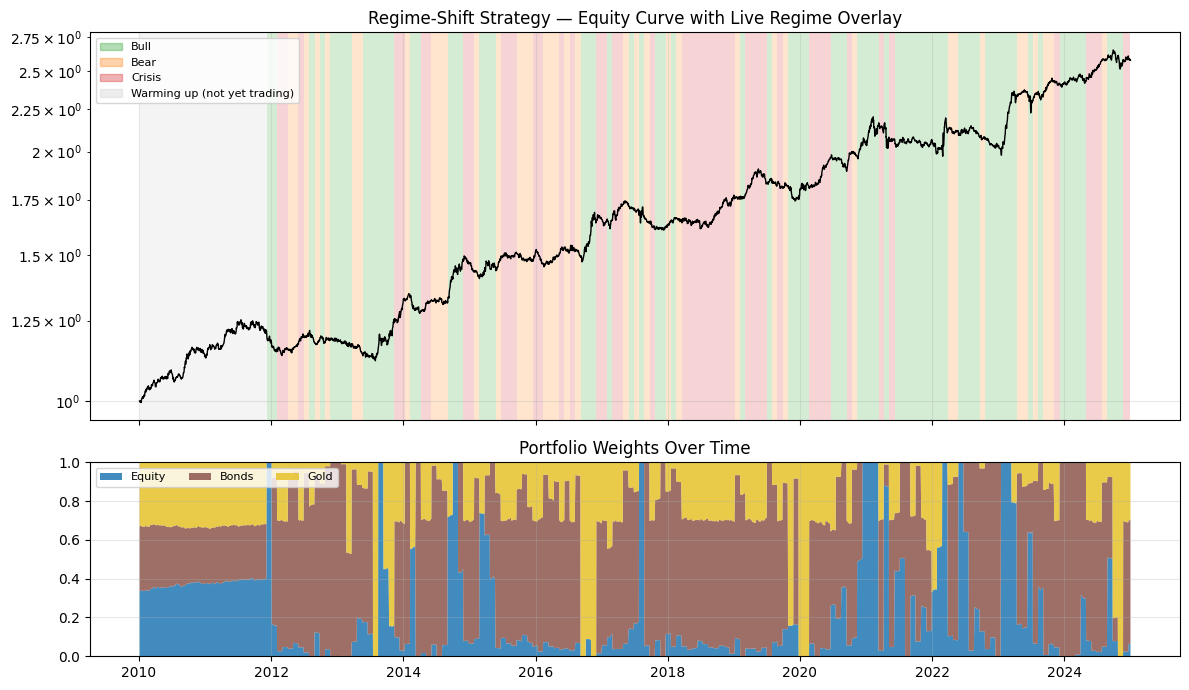

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]})

axes[0].plot(results["equity_curve"], color="black", linewidth=1)
axes[0].set_title("Regime-Shift Strategy — Equity Curve with Live Regime Overlay")
axes[0].set_yscale("log")

reg_hist = results["regime_history"]
prev_date, prev_regime = reg_hist.index[0], reg_hist.iloc[0]
for dt, reg in reg_hist.items():
    if reg != prev_regime:
        axes[0].axvspan(prev_date, dt, color=REGIME_COLORS[prev_regime], alpha=0.2, lw=0)
        prev_date, prev_regime = dt, reg
axes[0].axvspan(prev_date, reg_hist.index[-1], color=REGIME_COLORS[prev_regime], alpha=0.2, lw=0)
handles = [plt.Rectangle((0,0),1,1, color=REGIME_COLORS[r], alpha=0.35) for r in ["Bull","Bear","Crisis","Warming up"]]
axes[0].legend(handles, ["Bull","Bear","Crisis","Warming up (not yet trading)"], loc="upper left", fontsize=8)

axes[1].stackplot(
    results["weight_history"].index,
    results["weight_history"]["equity"], results["weight_history"]["bonds"], results["weight_history"]["gold"],
    labels=["Equity", "Bonds", "Gold"], colors=["#1f77b4", "#8c564b", "#e6c229"], alpha=0.85,
)
axes[1].set_title("Portfolio Weights Over Time")
axes[1].set_ylim(0, 1)
axes[1].legend(loc="upper left", ncol=3, fontsize=8)

plt.tight_layout()
plt.show()


## 5. Static Benchmarks

The whole point of this project is that a *dynamic* strategy should earn its
complexity - so it needs to be compared against boring, costless, static
baselines: classic **60/40** and naive **equal-weight** across the same 3
assets, both rebalanced monthly with no transaction costs (the textbook
version - this is deliberately a generous baseline).

In [10]:
bench_6040 = backtest.run_static_benchmark(df, {"equity": 0.6, "bonds": 0.4})
bench_eq = backtest.run_static_benchmark(df, {"equity": 1/3, "bonds": 1/3, "gold": 1/3})


## 6. Performance Tear Sheet

In [11]:
curves = {
    "Regime-Shift": results["equity_curve"],
    "60/40 (static)": bench_6040,
    "Equal-Weight (static)": bench_eq,
}
turnovers = {"Regime-Shift": results["turnover_history"]}

tear = metrics.build_tear_sheet(curves, turnovers)
tear


,Ann. Return,Ann. Vol,Sharpe,Sortino,Max Drawdown,Calmar,Avg Annual Turnover
Strategy,,,,,,,
Regime-Shift,6.29%,6.54%,0.97,1.42,-10.78%,0.58,609.99%
60/40 (static),6.72%,10.33%,0.68,1.01,-19.08%,0.35,n/a
Equal-Weight (static),5.73%,7.29%,0.80,1.24,-12.74%,0.45,n/a


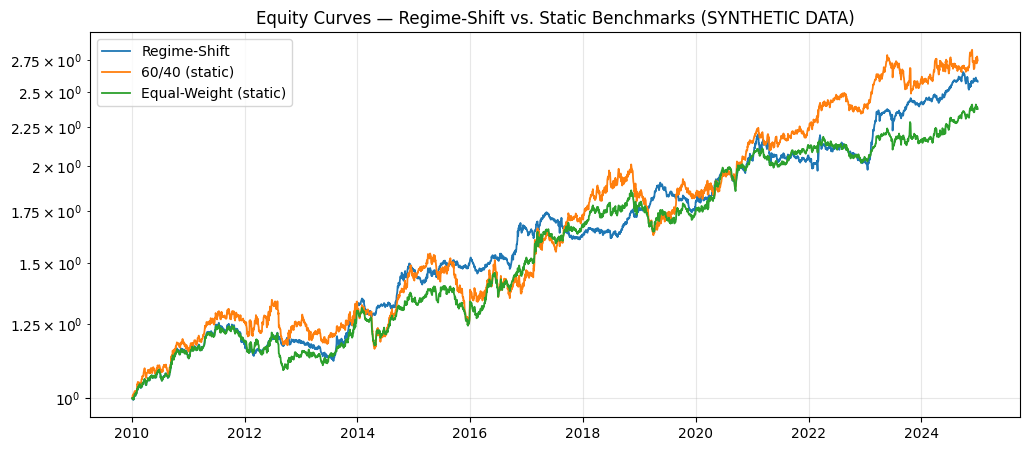

In [12]:
fig, ax = plt.subplots(figsize=(12, 5))
for name, ec in curves.items():
    ax.plot(ec, label=name, linewidth=1.3)
ax.set_yscale("log")
ax.set_title(f"Equity Curves — Regime-Shift vs. Static Benchmarks{' (SYNTHETIC DATA)' if IS_SYNTHETIC else ''}")
ax.legend()
plt.show()


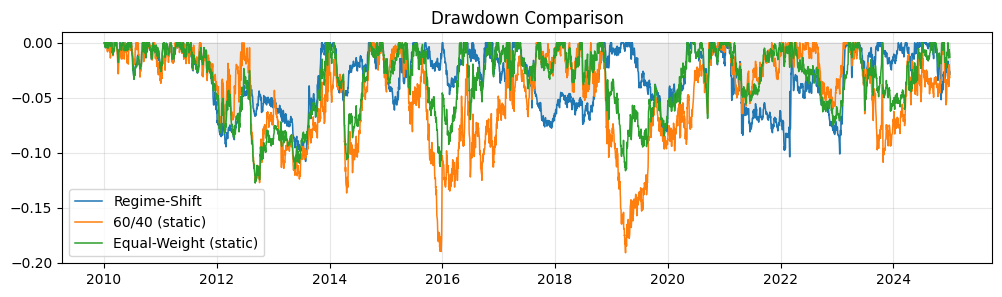

In [13]:
fig, ax = plt.subplots(figsize=(12, 3))
for name, ec in curves.items():
    dd = ec / ec.cummax() - 1
    ax.plot(dd, label=name, linewidth=1.1)
ax.set_title("Drawdown Comparison")
ax.legend()
ax.fill_between(curves["Regime-Shift"].index, 0, (curves["Regime-Shift"]/curves["Regime-Shift"].cummax()-1), alpha=0.08, color="black")
plt.show()


## 7. Discussion, Limitations 

**Read this section before quoting any number above in a recruitment interview.**

- **If `IS_SYNTHETIC` was `True` above**, every result in this notebook is a
  *plumbing check*, not a real finding - it proves the pipeline runs
  end-to-end without look-ahead bias or crashing, nothing more. Re-run with
  internet access to get a real backtest on SPY/AGG/GLD/VIX.
- **Corner solutions.** With only 3 assets, both max-Sharpe and min-variance
  QPs can land on corner solutions (e.g. 100% one asset) when the estimated
  `μ`/`Σ` are noisy - this is a known limitation of small-universe
  mean-variance optimization, not a bug. A production version would add a
  per-asset position cap (e.g. `w ≤ 0.7`) to dampen this.
- **Turnover vs. responsiveness trade-off.** Lower `cost_bps` or a longer
  `rebalance_every` reduces trading costs but makes the strategy slower to
  react to a real regime change - worth showing sensitivity on both if asked.
- **Regime-conditional `μ`/`Σ`** helps distinguish Crisis-day statistics from
  Bull-day statistics, but early in the backtest there may not be enough
  regime-matched history yet, in which case the code falls back to the flat
  trailing window (`min_regime_days` controls this).
- **HMM instability.** Gaussian HMMs can occasionally relabel states between
  consecutive refits if the underlying data is genuinely ambiguous - this is
  inherent to unsupervised regime detection, not something a "correct"
  implementation eliminates entirely.
- **What I'd add with more time:** a 4th "Recovery" state, macro features
  from FRED weighted into the HMM emissions (currently macro columns are
  fetched but only vol/return/VIX drive the classifier - a natural next
  step), and a no-trade band around target weights to cut turnover further.
